# Predictive Sales Modeling (Retail)

"""
Exploratory Data Analysis and Baseline Forecasting
for Retail Sales Prediction.

Dataset contains transaction-level retail sales.

Goal:
1. Understand customer purchase patterns
2. Convert transactions into time-series sales
3. Engineer forecasting features
4. Build baseline forecasting models
"""

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set(style="whitegrid")

plt.rcParams["figure.figsize"] = (12,6)

In [2]:
df = pd.read_csv("data/retail_sales.csv")

df.head()

,Transaction ID,date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24-11-2023,CUST001,Male,34,Beauty,3,50,150
1,2,27-02-2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13-01-2023,CUST003,Male,50,Electronics,1,30,30
3,4,21-05-2023,CUST004,Male,37,Clothing,1,500,500
4,5,06-05-2023,CUST005,Male,30,Beauty,2,50,100


In [3]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [4]:
df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y")

df = df.sort_values("date")

df.head()

,Transaction ID,date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
521,522,2023-01-01,CUST522,Male,46,Beauty,3,500,1500
179,180,2023-01-01,CUST180,Male,41,Clothing,3,300,900
558,559,2023-01-01,CUST559,Female,40,Clothing,4,300,1200
302,303,2023-01-02,CUST303,Male,19,Electronics,3,30,90
978,979,2023-01-02,CUST979,Female,19,Beauty,1,25,25


In [5]:
df.isnull().sum()

Transaction ID      0
date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

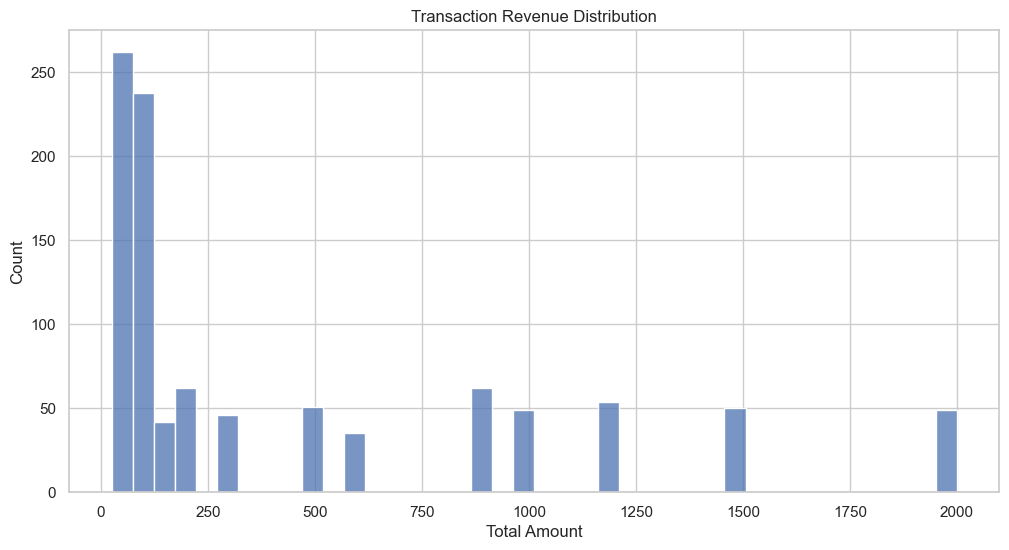

In [6]:
sns.histplot(df["Total Amount"], bins=40)

plt.title("Transaction Revenue Distribution")

plt.xlabel("Total Amount")

plt.show()

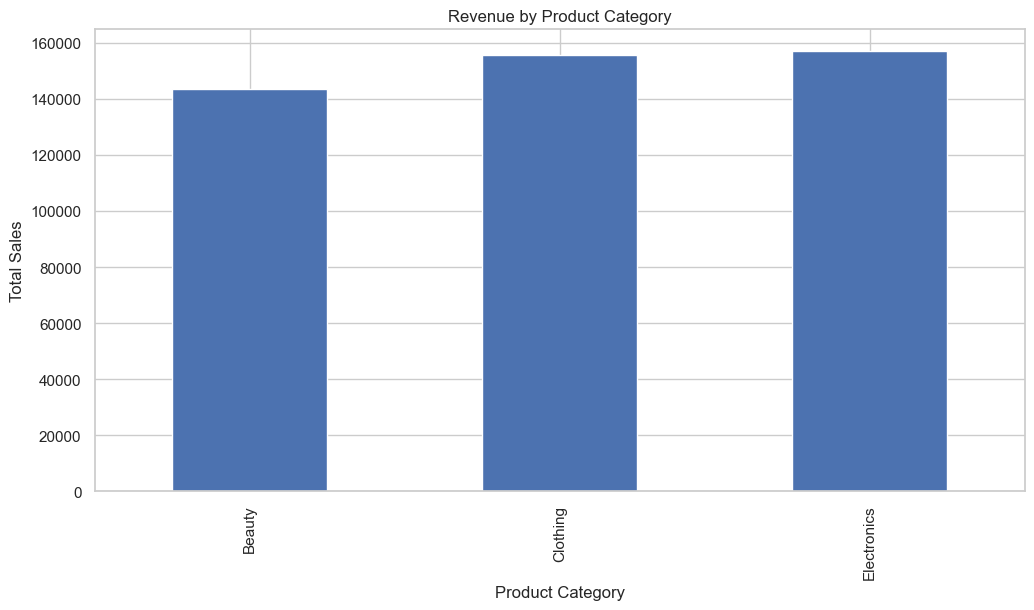

In [7]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()

category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")

plt.ylabel("Total Sales")

plt.show()

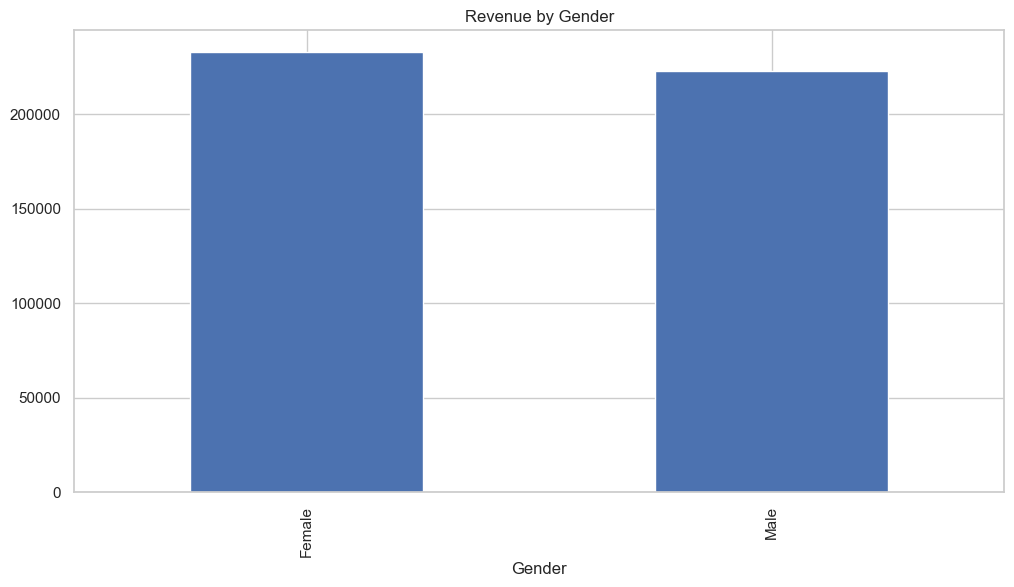

In [8]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()

gender_sales.plot(kind="bar")

plt.title("Revenue by Gender")

plt.show()

In [9]:
daily_sales = df.groupby("date")["Total Amount"].sum().reset_index()

daily_sales.columns = ["date", "sales"]

daily_sales.head()

,date,sales
0,2023-01-01,3600
1,2023-01-02,1765
2,2023-01-03,600
3,2023-01-04,1240
4,2023-01-05,1100


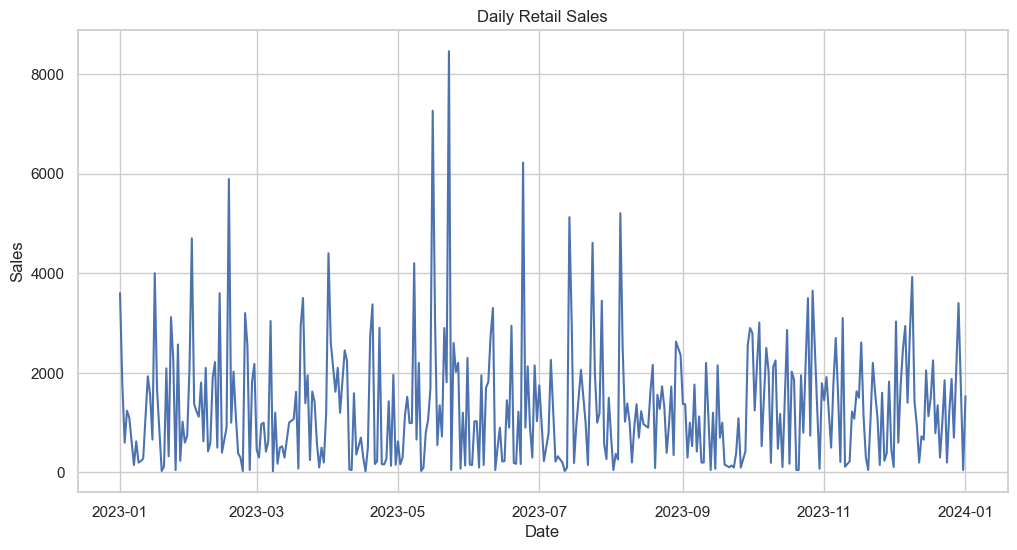

In [10]:
plt.plot(daily_sales["date"], daily_sales["sales"])

plt.title("Daily Retail Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

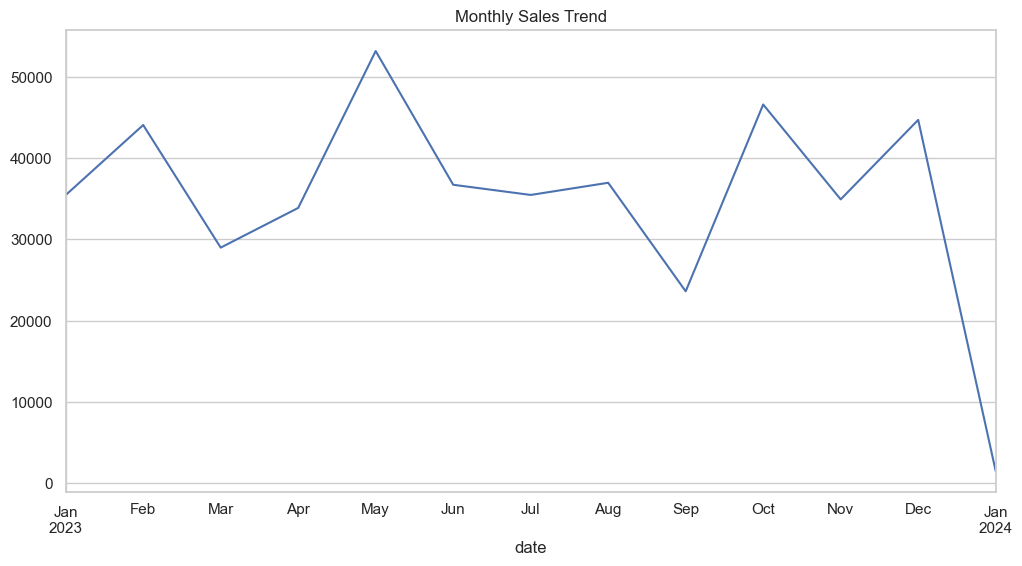

In [11]:
monthly_sales = daily_sales.groupby(daily_sales["date"].dt.to_period("M"))["sales"].sum()

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.show()

In [12]:
daily_sales["day_of_week"] = daily_sales["date"].dt.dayofweek
daily_sales["month"] = daily_sales["date"].dt.month

daily_sales["lag_1"] = daily_sales["sales"].shift(1)
daily_sales["lag_7"] = daily_sales["sales"].shift(7)
daily_sales["lag_14"] = daily_sales["sales"].shift(14)

daily_sales["rolling_mean_7"] = daily_sales["sales"].rolling(7).mean()

daily_sales = daily_sales.dropna()

daily_sales.head()

,date,sales,day_of_week,month,lag_1,lag_7,lag_14,rolling_mean_7
14,2023-01-16,4000,0,1,660.0,625.0,3600.0,1264.285714
15,2023-01-17,1645,1,1,4000.0,200.0,1765.0,1470.714286
16,2023-01-19,30,3,1,1645.0,230.0,600.0,1442.142857
17,2023-01-20,125,4,1,30.0,280.0,1240.0,1420.000000
18,2023-01-21,2090,5,1,125.0,1930.0,1100.0,1442.857143


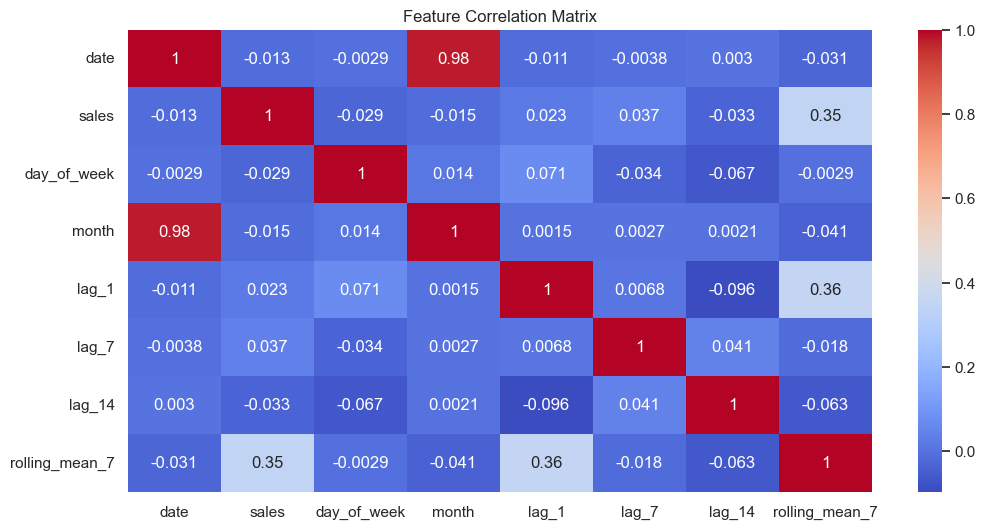

In [13]:
corr = daily_sales.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()


In [14]:
train = daily_sales.iloc[:-30].copy()

test = daily_sales.iloc[-30:].copy()

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (301, 8)
Test Shape: (30, 8)


In [15]:
test["naive_forecast"] = test["sales"].shift(1)

test.head()

,date,sales,day_of_week,month,lag_1,lag_7,lag_14,rolling_mean_7,naive_forecast
315,2023-12-02,3030,5,12,110.0,150.0,1130.0,1092.857143,NaN
316,2023-12-03,600,6,12,3030.0,1600.0,300.0,950.000000,3030.0
317,2023-12-04,1730,0,12,600.0,235.0,50.0,1163.571429,600.0
318,2023-12-05,2475,1,12,1730.0,390.0,1060.0,1461.428571,1730.0
319,2023-12-06,2940,2,12,2475.0,1825.0,2200.0,1620.714286,2475.0


In [16]:
test["moving_avg"] = test["sales"].rolling(7).mean()

test.head()

,date,sales,day_of_week,month,lag_1,lag_7,lag_14,rolling_mean_7,naive_forecast,moving_avg
315,2023-12-02,3030,5,12,110.0,150.0,1130.0,1092.857143,NaN,NaN
316,2023-12-03,600,6,12,3030.0,1600.0,300.0,950.000000,3030.0,NaN
317,2023-12-04,1730,0,12,600.0,235.0,50.0,1163.571429,600.0,NaN
318,2023-12-05,2475,1,12,1730.0,390.0,1060.0,1461.428571,1730.0,NaN
319,2023-12-06,2940,2,12,2475.0,1825.0,2200.0,1620.714286,2475.0,NaN


In [17]:
test = test.dropna()

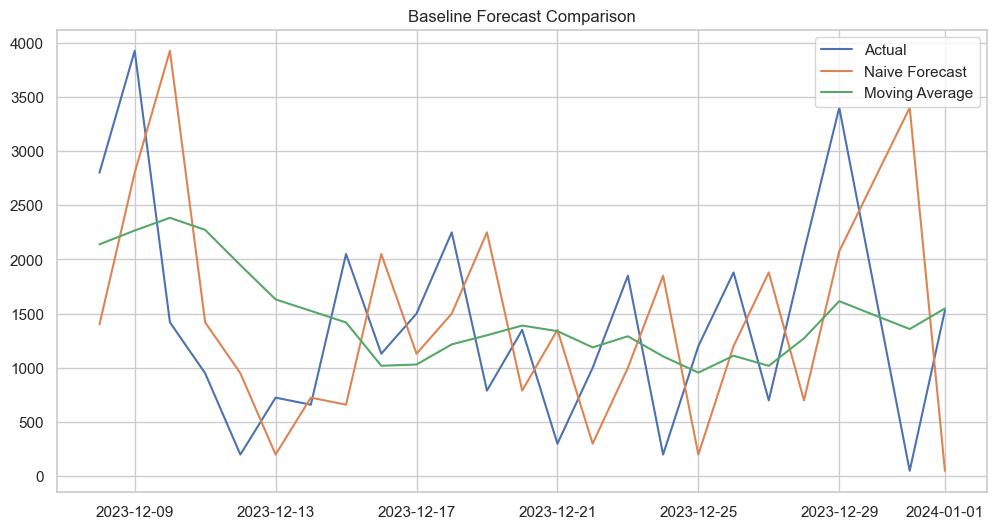

In [18]:
plt.plot(test["date"], test["sales"], label="Actual")

plt.plot(test["date"], test["naive_forecast"], label="Naive Forecast")

plt.plot(test["date"], test["moving_avg"], label="Moving Average")

plt.legend()

plt.title("Baseline Forecast Comparison")

plt.show()

In [19]:
y_true = test["sales"]

y_pred = test["naive_forecast"]

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("Naive Forecast MAE:", mae)

print("Naive Forecast RMSE:", rmse)

Naive Forecast MAE: 1122.0833333333333
Naive Forecast RMSE: 1314.002314812776


In [20]:
y_pred = test["moving_avg"]

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("Moving Average MAE:", mae)

print("Moving Average RMSE:", rmse)

Moving Average MAE: 785.7440476190477
Moving Average RMSE: 935.2536920736613


"""
Key Insights

• Retail revenue varies across product categories
• Daily sales patterns contain predictive signals
• Lag features help forecasting models learn temporal patterns
• Baseline models provide benchmarks before ML models

Next Steps

• Train PyTorch neural networks
• Implement LSTM time series models
• Compare model performance against baselines
"""